In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Neuron

In [38]:
def neuron(inputs, weights, bias):
  return np.dot(inputs, weights) + bias

In [39]:
inputs = np.array([200, 3, 1])
weights = np.array([0.1, 50, 100])
bias = 2000

x = neuron(inputs, weights, bias)

Activation function


Sigmoid

In [40]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

ReLu

In [41]:
def relu(x):
  return np.maximum(0, x)

Activated output

In [42]:
activated_output = relu(neuron(inputs, weights, bias))

print(f'Activated output using ReLu: {activated_output}')

Activated output using ReLu: 2270.0


# Forward Propagation

In [43]:
def forward_pass(X, W1, b1, W2, b2, activation_fn):

  # hidden layer
  Z1 = np.dot(W1, X) + b1 # Z1 = neuron(X, W1, b1)
  A1 = activation_fn(Z1)

  # output layer
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)

  return A2

In [44]:
# sample data
np.random.seed(42)
X = np.random.rand(3, 1)
W1 = np.random.randn(4, 3)
b1 = np.zeros((4, 1))
W2 = np.random.randn(1, 4)
b2 = np.zeros((1, 1))

In [45]:
output = forward_pass(X, W1, b1, W2, b2, relu)

In [46]:
print(f'Output using relu is: {output}')

Output using relu is: [[0.48134351]]


# Backward Propagation

The version of forward pass that we need for backward pass

In [47]:
def forward_pass(X, W1, b1, W2, b2, activation_fn):

  # hidden layer
  Z1 = np.dot(W1, X) + b1 # Z1 = neuron(X, W1, b1)
  A1 = activation_fn(Z1)

  # output layer
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)

  return Z1, A1, Z2, A2

In [48]:
def backward_pass(X, y, Z1, A1, Z2, A2, activation_fn_derivative):
  m = X.shape[1]

  # output layer gradients
  dZ2 = A2 - y
  dW2 = (1/m) * np.dot(dZ2, A1.T)
  db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

  # hidden layer gradients
  dA1 = np.dot(W2.T, dZ2)
  dZ1 = dA1 * activation_fn_derivative(Z1)
  dW1 = (1/m) * np.dot(dZ1, X.T)
  db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

  gradients = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}

  return gradients

Derivatives of activation functions

In [49]:
def sigmoid_derivative(a):
  return a * (1 - a)

In [50]:
def relu_derivative(z):
  return np.greater(z, 0).astype(float)

In [51]:
X = np.random.randn(3, 1)
y = np.array([[1]])

W1 = np.random.randn(4, 3)
b1 = np.zeros((4, 1))
W2 = np.random.randn(1, 4)
b2 = np.zeros((1, 1))

Z1, A1, Z2, A2 = forward_pass(X, W1, b1, W2, b2, relu)
gradients = backward_pass(X, y, Z1, A1, Z2, A2, relu_derivative)

In [52]:
print('Gradients: ')
for key, value in gradients.items():
  print(f'{key}: {value}')

Gradients: 
dW1: [[ 0.          0.          0.        ]
 [-0.71229149  0.67635924  2.89622569]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]]
db1: [[0.        ]
 [1.13156446]
 [0.        ]
 [0.        ]]
dW2: [[ 0.         -1.51073959  0.          0.        ]]
db2: [[-0.89443314]]


Gradient descent

In [59]:
def update_parameters(W1, b1, W2, b2, gradients, learning_rate):
  W1 -= learning_rate * gradients['dW1']
  b1 -= learning_rate * gradients['db1']
  W2 -= learning_rate * gradients['dW2']
  b2 -= learning_rate * gradients['db2']

  return W1, b1, W2, b2

Cost function

In [54]:
def compute_cost(A2, y):
  m = y.shape[1]
  A2 = np.clip(A2, 1e-9, 1 - 1e-9) # numerical stability, so the computation doesn't break
  cost = - (1/m) * np.sum(y * np.log(A2) + (1 - y) * np.log(1 - A2))

  return cost

Each epoch:
1. Forward pass -> predictions
2. Compute cost -> how wrong are we
3. Backward pass -> gradients
4. Update parameters -> improve model

Repeat

In [55]:
# dataset
X = np.random.randn(3, 100)
y = (np.random.rand(1, 100) > 0.5).astype(int)

In [62]:
# hyperparameters
learning_rate = 0.01
epochs = 200

In [63]:
# parameters
W1 = np.random.randn(4, 3)
b1 = np.zeros((4, 1))
W2 = np.random.randn(1, 4)
b2 = np.zeros((1, 1))

In [64]:
losses = []

#training loop
for i in range(epochs):
  # forward pass
  Z1, A1, Z2, A2 = forward_pass(X, W1, b1, W2, b2, relu)

  # compute cost
  cost = compute_cost(A2, y)
  losses.append(cost)

  # backward pass
  gradients = backward_pass(X, y, Z1, A1, Z2, A2, relu_derivative)

  # update parameters
  W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, gradients, learning_rate)

  # print loss for every 100 epochs
  if i % 10 == 0:
    print(f'Epoch {i}, Cost: {np.squeeze(cost)}')






# once we have trained the network, let's see how well it had learned

# final prediction
Z1, A1, Z2, A2 = forward_pass(X, W1, b1, W2, b2, relu)

print('Final output: ', A2)

Epoch 0, Cost: 1.1639511259834998
Epoch 10, Cost: 1.0934370255030899
Epoch 20, Cost: 1.0306500805541525
Epoch 30, Cost: 0.9766882093036029
Epoch 40, Cost: 0.9312058455195512
Epoch 50, Cost: 0.8933670089665366
Epoch 60, Cost: 0.8621413484148177
Epoch 70, Cost: 0.8368457814792764
Epoch 80, Cost: 0.8162255444674991
Epoch 90, Cost: 0.7991152676698231
Epoch 100, Cost: 0.7850167608906433
Epoch 110, Cost: 0.773378029057005
Epoch 120, Cost: 0.7638677973387844
Epoch 130, Cost: 0.7558205200110778
Epoch 140, Cost: 0.7489328984938557
Epoch 150, Cost: 0.7429698740876852
Epoch 160, Cost: 0.7377494980321087
Epoch 170, Cost: 0.7331306827636227
Epoch 180, Cost: 0.729003615172549
Epoch 190, Cost: 0.7252823923704652
Final output:  [[0.90191967 0.53038517 0.62744548 0.45797299 0.25682526 0.4771309
  0.55078147 0.3592669  0.29785283 0.37729734 0.5309296  0.7053187
  0.4845806  0.97333043 0.46066797 0.54620493 0.77511663 0.38790912
  0.5136776  0.55078147 0.55078147 0.43655008 0.78337208 0.47179718
  0.5356

Plot loss curve

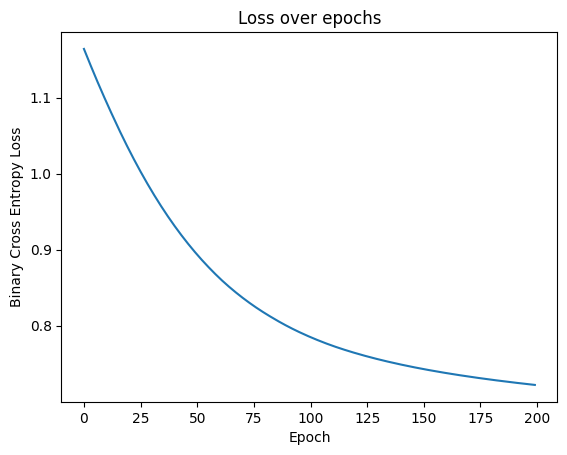

In [65]:
plt.plot(losses)
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross Entropy Loss')
plt.show()